# DistilGPT2: Alpaca fine-tuning + MLflow serve

Hive: `pysparktest.alpaca`. Сначала выполните DAG `alpaca_postgres_to_hive`.

Notebook обучает `distilgpt2` на Alpaca-формате, регистрирует модель как `distilgpt-causal-lm` в MLflow Production и проверяет serve на порту `5002`.

После открытия: **Kernel → Restart** и **Run All**.

In [ ]:
# Если образ Jupyter старый, раскомментируйте и перезапустите kernel:
# %pip install -q "transformers>=4.36,<5" "accelerate>=1.1.0" torch torchvision

In [1]:
%matplotlib inline

import importlib
import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from pyspark.sql import functions as F

_utils = Path("/home/jovyan/work/alpaca_llm_utils.py")
if _utils.is_file():
    _spec = importlib.util.spec_from_file_location("alpaca_llm_utils", _utils)
    alu = importlib.util.module_from_spec(_spec)
    sys.modules["alpaca_llm_utils"] = alu
    _spec.loader.exec_module(alu)
else:
    import alpaca_llm_utils as alu
    alu = importlib.reload(alu)

from hive_ddl_utils import create_hive_spark_session, read_alpaca_hive, wait_hive_ports

In [2]:
wait_hive_ports()
spark = create_hive_spark_session(app_name="distilgpt-alpaca-eda")
sdf = read_alpaca_hive(spark)
stats_df = alu.with_text_lengths(sdf).cache()
print(f"Строк: {stats_df.count():,}")

Ожидание metastore hive-metastore:9083 ...
  metastore доступен.
Ожидание hiveserver2 hive-server:10000 ...
  hiveserver2 доступен.


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/09 21:32:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


=== SELECT * FROM pysparktest.alpaca (Hive metastore) ===


Строк: 52,002


In [3]:
print("=== EDA summary ===")
for k, v in alu.eda_summary_spark(stats_df):
    print(f"  {k}: {v}")

stats_df.select(
    "instruction", "input", "output", "instruction_len", "output_len", "has_input"
).show(3, truncate=70)

=== EDA summary ===


  rows: 52002
  instruction_with_duplicates: 0
  empty_input_pct: 60.23
  instruction_len_median: 57
  output_len_median: 185
  text_len_median: 443
  output_len_p95: 746
+------------------------------------+-----+----------------------------------------------------------------------+---------------+----------+---------+
|                         instruction|input|                                                                output|instruction_len|output_len|has_input|
+------------------------------------+-----+----------------------------------------------------------------------+---------------+----------+---------+
|Give three tips for staying healthy.|     |1.Eat a balanced diet and make sure to include plenty of fruits and...|             36|       202|    false|
|  What are the three primary colors?|     |                   The three primary colors are red, blue, and yellow.|             34|        51|    false|
|  Describe the structure of an atom.|     |An atom is made up o

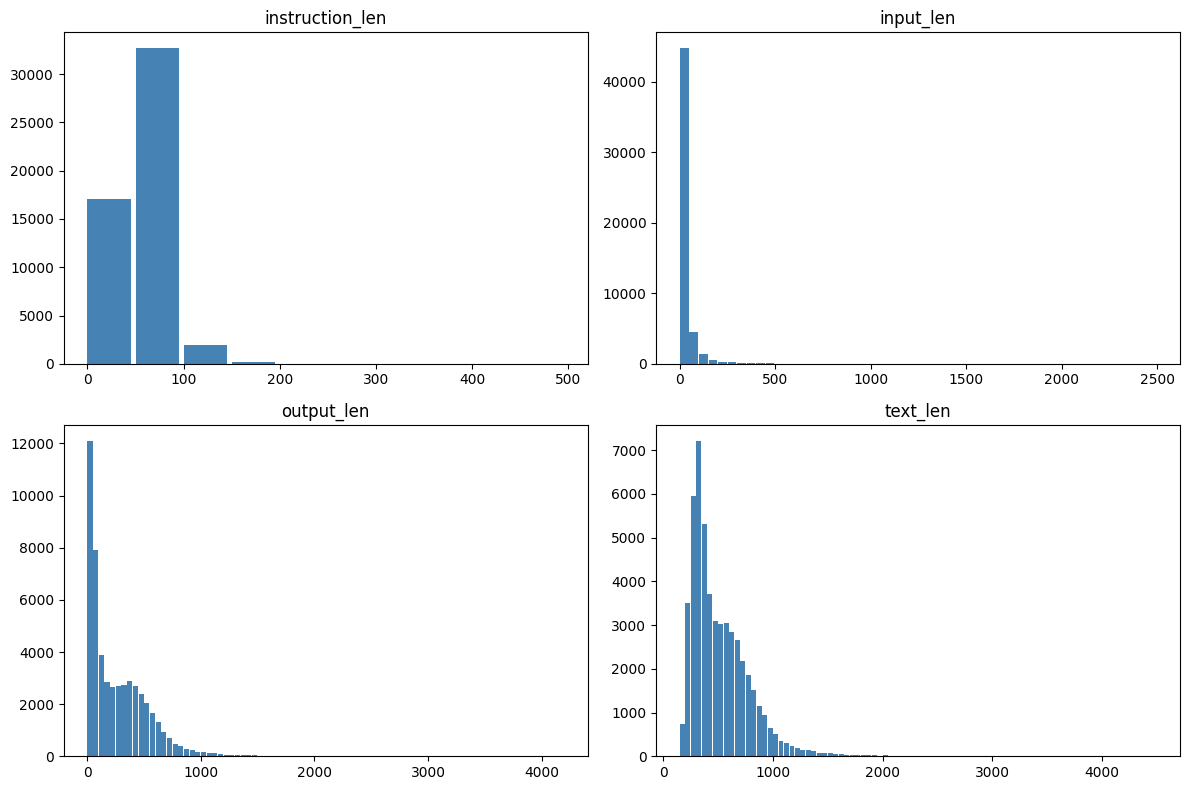

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["instruction_len", "input_len", "output_len", "text_len"]):
    bins, cnt = alu.length_histogram(stats_df, col)
    ax.bar(bins, cnt, width=45, align="edge", color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Fine-tuning DistilGPT2

База: `distilgpt2`. Это небольшая causal LM, поэтому notebook обучает full model без LoRA и сохраняет веса в `models/alpaca-distilgpt2`, которые затем монтируются в контейнер serve на порт `5002`.

In [5]:
alu = importlib.reload(alu)

MAX_TRAIN_SAMPLES = 500
MAX_LENGTH = 256
MAX_STEPS = 50
BATCH_SIZE = 2
CPU_THREADS = 6
MODEL_NAME = alu.DEFAULT_DISTILGPT2_MODEL
OUTPUT_DIR = alu.DEFAULT_DISTILGPT2_OUTPUT_DIR
EXPERIMENT_NAME = "distilgpt_alpaca_finetune"
REGISTERED_MODEL_NAME = "distilgpt-causal-lm"

train_sdf, eval_sdf = alu.build_train_eval_spark(
    stats_df,
    max_samples=MAX_TRAIN_SAMPLES,
    test_frac=0.1,
    seed=42,
)

prompt_sample_row = stats_df.select(
    "text", "instruction", "input", "output"
).limit(1).collect()[0]

try:
    stats_df.unpersist()
except Exception:
    pass

print(f"train: {train_sdf.count():,}, eval: {eval_sdf.count():,}")
print(f"model: {MODEL_NAME}")
print(f"output_dir: {OUTPUT_DIR}")
print(f"max_steps: {MAX_STEPS}")
print(f"cpu_threads: {CPU_THREADS}")

train: 453, eval: 47
model: distilgpt2
output_dir: /home/jovyan/work/models/alpaca-distilgpt2
max_steps: 50
cpu_threads: 6


In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

train_tok, eval_tok = alu.spark_texts_to_tokenized(
    train_sdf,
    eval_sdf,
    tokenizer,
    max_length=MAX_LENGTH,
    model_name=MODEL_NAME,
)

# Пары для метрик serve собираем до spark.stop().
eval_prompt_pairs = alu.collect_eval_prompt_pairs(eval_sdf, max_samples=20)
print(f"tokenized: train={len(train_tok)}, eval={len(eval_tok)}")
print(f"eval pairs for serve metrics: {len(eval_prompt_pairs)}")

try:
    stats_df.unpersist()
except Exception:
    pass
spark.stop()

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tokenized: train=453, eval=47
eval pairs for serve metrics: 20


In [7]:
trainer, run_id = alu.train_causal_lm(
    train_tok,
    eval_tok,
    model_name=MODEL_NAME,
    output_dir=OUTPUT_DIR,
    max_steps=MAX_STEPS,
    batch_size=BATCH_SIZE,
    learning_rate=5e-5,
    experiment_name=EXPERIMENT_NAME,
    register_model_name=REGISTERED_MODEL_NAME,
    register_stage="Production",
    use_lora=False,
    gradient_checkpointing=False,
    trust_remote_code=False,
    cpu_threads=CPU_THREADS,
)

artifact_location: mlflow-artifacts:/
MLflow tracking: http://mlflow:5000
UI в браузере: http://localhost:5000
Experiment: distilgpt_alpaca_finetune
PyTorch device: cpu (cuda_available=False)
CPU threads: torch=6 interop=2
train: start (max_steps=50, logging every 10 step(s), eval every 12 step(s))


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
12,3.247200,2.481995
24,2.661800,2.161602
36,2.243400,2.058067
48,2.199800,2.025832


[step 1/50] train_loss=3.2592, lr=5.00e-05
[step 10/50] train_loss=3.2472, lr=4.10e-05
[step 12/50] eval_loss=2.4820
[step 20/50] train_loss=2.6618, lr=3.10e-05
[step 24/50] eval_loss=2.1616
[step 30/50] train_loss=2.2434, lr=2.10e-05
[step 36/50] eval_loss=2.0581
[step 40/50] train_loss=2.1998, lr=1.10e-05
[step 48/50] eval_loss=2.0258
[step 50/50] train_loss=2.2534, lr=1.00e-06
train: done — mean train_loss=2.5213
evaluate: start


[step 50/50] eval_loss=2.0246
  eval_loss=2.0246
  eval_runtime=11.1875
  eval_samples_per_second=4.2010
  eval_steps_per_second=2.1450
  epoch=0.2203
evaluate: done
save: start


Device set to use cpu


save: done
mlflow log_model: start


2026/06/09 21:35:48 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.27.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torchvision==0.27.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/09 21:35:57 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.27.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torchvision==0.27.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
Successfully registered model 'distilgpt-causal-lm'.
2026/06/09 21:36:00 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: distilgpt-causal-lm, version 1

  → causal LM в MLflow (flavor transformers): 'model'
mlflow log_model: done
🏃 View run distilgpt2 at: http://mlflow:5000/#/experiments/2/runs/dfdc6e13d263459d80ff5466948ace75
🧪 View experiment at: http://mlflow:5000/#/experiments/2
Локально: /home/jovyan/work/models/alpaca-distilgpt2
MLflow run_id: dfdc6e13d263459d80ff5466948ace75
Model Registry: distilgpt-causal-lm v1 → stage 'Production'
Serve: docker compose up -d mlflow-serve-alpaca --force-recreate


Created version '1' of model 'distilgpt-causal-lm'.
/home/jovyan/work/mlflow_utils.py:1077: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


## MLflow Registry и serve

- UI: http://localhost:5000 → Models → `distilgpt-causal-lm` (Production)
- Serve: http://localhost:5002 через compose service `mlflow-serve-alpaca`
- После обучения/перерегистрации: `docker compose up -d mlflow-serve-alpaca --force-recreate`

In [8]:
import importlib
import mlflow_utils as mu

mu = importlib.reload(mu)

print(f"MLflow UI: {mu.mlflow_ui_url()} → Models → {mu.DISTILGPT_REGISTERED_MODEL_NAME}")
print(f"Serve:     {mu.distilgpt_serve_ui_url()}/invocations")
if "run_id" in globals():
    print(f"run_id:    {run_id}")
print("Restart serve after training:")
print("docker compose up -d mlflow-serve-alpaca --force-recreate")

MLflow UI: http://localhost:5000 → Models → distilgpt-causal-lm
Serve:     http://localhost:5002/invocations
run_id:    dfdc6e13d263459d80ff5466948ace75
Restart serve after training:
docker compose up -d mlflow-serve-alpaca --force-recreate


## Проверка генерации через serve `:5002`

In [9]:
if "prompt_sample_row" not in globals():
    raise RuntimeError("Сначала выполните ячейки подготовки данных и токенизации.")

row = prompt_sample_row
prompt = alu.prompt_for_generation_from_row(row)

print("=== Instruction ===")
print(row.instruction[:300])
if row.input:
    print("=== Input ===")
    print(row.input[:200])
print("\n=== Эталон ===")
print(row.output[:400])

=== Instruction ===
Give three tips for staying healthy.

=== Эталон ===
1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. 
2. Exercise regularly to keep your body active and strong. 
3. Get enough sleep and maintain a consistent sleep schedule.


In [10]:
# Запустите в терминале после обучения, если serve еще не пересоздан:
# docker compose up -d mlflow-serve-alpaca --force-recreate

uri = mu.wait_for_distilgpt_serve(max_wait_sec=600)
print(uri)
print(mu.predict_distilgpt_via_serve(prompt, max_new_tokens=120, serve_uri=uri, timeout=600))

KeyboardInterrupt: 

## Метрики генерации serve

ROUGE-L, chrF, `refusal_rate`, средняя длина ответа — сравнение с эталоном `output` на eval-подвыборке.

In [ ]:
# %pip install -q rouge-score sacrebleu  # если в образе Jupyter этих пакетов нет

if "eval_prompt_pairs" not in globals() or not eval_prompt_pairs:
    raise RuntimeError("Нет eval_prompt_pairs: выполните ячейку tokenization до spark.stop().")

uri = mu.wait_for_distilgpt_serve(max_wait_sec=600)
serve_metrics = mu.evaluate_deployed_distilgpt(
    eval_prompt_pairs,
    serve_uri=uri,
    max_samples=20,
    max_new_tokens=128,
    timeout=600,
    show_examples=3,
    mlflow_log=True,
    experiment_name=EXPERIMENT_NAME,
    run_name="distilgpt_serve_generation_eval",
)
serve_metrics